# 04 - Retention hypothesis tests

**Goal:** test whether retention differs between the two versions, with confidence
intervals, cross-checks and a multiple-testing correction.

This is the core result. Every number is calculated by hand first and only then confirmed
with statsmodels and a chi-square test, so nothing rests on a black box.

In [1]:
import pandas as pd                                                   # tables
import numpy as np                                                    # maths
import matplotlib.pyplot as plt                                       # charts
from scipy import stats                                               # normal distribution and chi-square test
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep   # ready-made proportion tests
from statsmodels.stats.multitest import multipletests                 # multiple-testing correction
from pathlib import Path                                              # file paths

pd.set_option("display.max_columns", None)                            # never hide columns when printing tables
pd.set_option("display.width", 200)                                   # allow wide tables to print on one line

In [2]:
ROOT = Path.cwd()                                                     # folder the notebook runs in
if ROOT.name == "notebooks":                                          # if inside notebooks/...
    ROOT = ROOT.parent                                                # ...go up to the project root
FIG_DIR = ROOT / "reports" / "figures"                                # charts folder
df = pd.read_csv(ROOT / "data" / "processed" / "cookie_cats_clean.csv")   # cleaned data
alpha = 0.05                                                          # significance level from the pre-analysis plan

In [3]:
counts = df.groupby("version").agg(                                   # group by version and compute:
    players=("userid", "count"),                                      # number of players
    d1_retained=("retention_1", "sum"),                               # sum of True values = retained players on day 1
    d7_retained=("retention_7", "sum"),                               # retained players on day 7
)
print(counts)                                                         # show the table

         players  d1_retained  d7_retained
version                                   
gate_30    44700        20034         8502
gate_40    45489        20119         8279


**Checkpoint:** gate_30 has 44,700 players, 20,034 retained on D1 and 8,502 on D7.
gate_40 has 45,489 players, 20,119 on D1 and 8,279 on D7.

## Two-proportion z-test, calculated by hand

The test assumes H0 (no difference) is true, so it pools both groups into one shared rate
to estimate the noise. The confidence interval does not assume H0, so it uses each group's
own rate. That is why two different standard errors appear below.

In [4]:
results = []                                                          # empty list to collect one row per metric
for metric, column in [("D1 retention", "d1_retained"), ("D7 retention", "d7_retained")]:   # loop over both metrics
    x_control = counts.loc["gate_30", column]                         # retained players in control
    n_control = counts.loc["gate_30", "players"]                      # players in control
    x_treat = counts.loc["gate_40", column]                           # retained players in treatment
    n_treat = counts.loc["gate_40", "players"]                        # players in treatment
    p_control = x_control / n_control                                 # control retention rate
    p_treat = x_treat / n_treat                                       # treatment retention rate
    diff = p_treat - p_control                                        # absolute difference (treatment minus control)
    p_pooled = (x_control + x_treat) / (n_control + n_treat)          # pooled rate assuming H0 (no difference) is true
    se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_control + 1 / n_treat))   # standard error under H0 (used for the test)
    z_stat = diff / se_pooled                                         # how many standard errors away from zero the difference is
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))                   # two-sided p-value
    se_unpooled = np.sqrt(p_control * (1 - p_control) / n_control + p_treat * (1 - p_treat) / n_treat)   # standard error NOT assuming H0 (used for the CI)
    z_crit = stats.norm.ppf(1 - alpha / 2)                            # 1.96 for a 95% interval
    ci_low = diff - z_crit * se_unpooled                              # lower end of the 95% CI
    ci_high = diff + z_crit * se_unpooled                             # upper end of the 95% CI
    relative_lift = diff / p_control                                  # difference as a % of the control rate
    results.append({                                                  # store everything for this metric
        "metric": metric,
        "control_rate_pct": 100 * p_control,
        "treatment_rate_pct": 100 * p_treat,
        "diff_pp": 100 * diff,
        "ci_low_pp": 100 * ci_low,
        "ci_high_pp": 100 * ci_high,
        "relative_lift_pct": 100 * relative_lift,
        "z_stat": z_stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results)                                    # list of dictionaries -> table
print(results_df.round(4))                                            # show the results

         metric  control_rate_pct  treatment_rate_pct  diff_pp  ci_low_pp  ci_high_pp  relative_lift_pct  z_stat  p_value
0  D1 retention           44.8188             44.2283  -0.5905    -1.2392      0.0582            -1.3176 -1.7841   0.0744
1  D7 retention           19.0201             18.2000  -0.8201    -1.3282     -0.3121            -4.3119 -3.1644   0.0016


**Checkpoint**

| Metric | Control | Treatment | Diff (pp) | 95% CI (pp) | Relative | z | p |
|---|---|---|---|---|---|---|---|
| D1 | 44.82% | 44.23% | -0.59 | -1.24 to +0.06 | -1.32% | -1.784 | 0.0744 |
| D7 | 19.02% | 18.20% | -0.82 | -1.33 to -0.31 | -4.31% | -3.164 | 0.0016 |

- **D7:** if moving the gate truly made no difference, a gap at least this large in either
  direction would appear only about 0.16% of the time. The interval sits entirely below zero,
  so the data points to gate_40 lowering D7 retention by somewhere between 0.31 and 1.33 pp.
- **D1:** p is above 0.05 and the interval crosses zero. The data cannot rule out "no effect",
  but it also cannot rule out a drop of up to about 1.24 pp. The point estimate points the
  same way as D7.

In [5]:
for metric, column in [("D1 retention", "d1_retained"), ("D7 retention", "d7_retained")]:   # loop over both metrics
    count_array = np.array([counts.loc["gate_40", column], counts.loc["gate_30", column]])       # [treatment, control] successes
    nobs_array = np.array([counts.loc["gate_40", "players"], counts.loc["gate_30", "players"]])  # [treatment, control] players
    z_sm, p_sm = proportions_ztest(count=count_array, nobs=nobs_array, alternative="two-sided")  # statsmodels z-test
    ci_sm = confint_proportions_2indep(count_array[0], nobs_array[0], count_array[1], nobs_array[1], method="wald", compare="diff", alpha=alpha)  # CI for treatment - control
    print(f"{metric}: z = {z_sm:.4f}, p = {p_sm:.5f}, 95% CI = ({100 * ci_sm[0]:.3f} pp, {100 * ci_sm[1]:.3f} pp)")   # compare with the hand calculation

D1 retention: z = -1.7841, p = 0.07441, 95% CI = (-1.239 pp, 0.058 pp)
D7 retention: z = -3.1644, p = 0.00155, 95% CI = (-1.328 pp, -0.312 pp)


**Checkpoint:** identical z-values, p-values and intervals to the hand calculation above.

In [6]:
for metric, column in [("D1 retention", "d1_retained"), ("D7 retention", "d7_retained")]:   # loop over both metrics
    retained = counts[column].values                                  # retained players per group
    not_retained = counts["players"].values - retained                # not-retained players per group
    table_2x2 = np.column_stack([retained, not_retained])             # 2 x 2 table: rows = groups, columns = retained / not
    chi2, p_chi, dof, expected_table = stats.chi2_contingency(table_2x2, correction=False)   # no continuity correction so it matches the z-test
    print(f"{metric}: chi-square = {chi2:.4f}, p = {p_chi:.5f}")      # compare with the z-test

D1 retention: chi-square = 3.1830, p = 0.07441
D7 retention: chi-square = 10.0132, p = 0.00155


**Checkpoint:** D1 chi-square 3.1830 (p 0.07441), D7 chi-square 10.0132 (p 0.00155).
For a 2x2 table the chi-square statistic is exactly the squared z: -1.7841^2 = 3.183 and
-3.1644^2 = 10.013.

In [7]:
holm_reject, holm_p, _, _ = multipletests(results_df["p_value"], alpha=alpha, method="holm")   # Holm correction
results_df["p_value_holm"] = holm_p                                   # adjusted p-values
results_df["significant_after_holm"] = holm_reject                    # True if still significant
print(results_df[["metric", "diff_pp", "p_value", "p_value_holm", "significant_after_holm"]].round(5))   # focused view

         metric  diff_pp  p_value  p_value_holm  significant_after_holm
0  D1 retention -0.59052  0.07441       0.07441                   False
1  D7 retention -0.82013  0.00155       0.00311                    True


**Checkpoint:** D1 Holm p 0.0744 (not significant), D7 Holm p 0.0031 (still significant).

Holm sorts the p-values from smallest to largest, multiplies the smallest by the number of
tests (2), the next by 1, and keeps the order consistent. D7 survives the correction for
having tested two metrics.

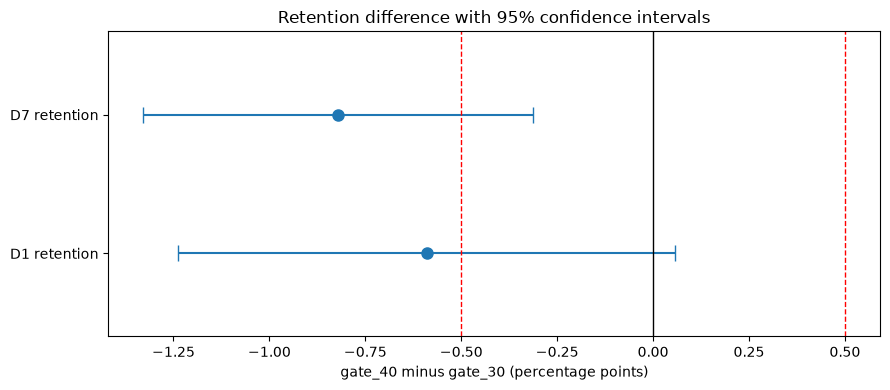

In [8]:
practical_threshold_pp = 0.5                                          # smallest change the business cares about (from the pre-analysis plan)
fig, ax = plt.subplots(figsize=(9, 4))                                # empty chart
y_positions = np.arange(len(results_df))                              # one row per metric: 0, 1
errors = [results_df["diff_pp"] - results_df["ci_low_pp"], results_df["ci_high_pp"] - results_df["diff_pp"]]   # distance from the point to each CI end
ax.errorbar(results_df["diff_pp"], y_positions, xerr=errors, fmt="o", capsize=6, markersize=8)   # points with horizontal CI bars
ax.axvline(0, color="black", linewidth=1)                             # zero line = no difference
ax.axvline(-practical_threshold_pp, color="red", linestyle="--", linewidth=1)   # practical threshold (negative side)
ax.axvline(practical_threshold_pp, color="red", linestyle="--", linewidth=1)    # practical threshold (positive side)
ax.set_yticks(y_positions)                                            # place metric labels
ax.set_yticklabels(results_df["metric"])                              # metric names on the y-axis
ax.set_ylim(-0.6, len(results_df) - 0.4)                              # remove empty space above and below the two rows
ax.set_xlabel("gate_40 minus gate_30 (percentage points)")            # x label
ax.set_title("Retention difference with 95% confidence intervals")    # title
fig.tight_layout()                                                    # tidy
fig.savefig(FIG_DIR / "05_retention_diff_ci.png", dpi=150)            # save
plt.show()                                                            # display

The D7 point estimate (-0.82 pp) sits beyond the -0.5 pp practical threshold, but the
interval runs from -1.33 to -0.31 pp. So the effect is clearly negative and most plausibly
meaningful, though the true drop could be somewhat smaller than 0.5 pp. The memo says it
exactly that way.

In [9]:
results_df.to_csv(ROOT / "data" / "processed" / "retention_test_results.csv", index=False)   # full results table
app_summary = counts.reset_index()                                    # make version a normal column
app_summary.to_csv(ROOT / "data" / "processed" / "summary_by_version.csv", index=False)      # tiny summary the Streamlit app will read
print(app_summary)                                                    # confirm contents

   version  players  d1_retained  d7_retained
0  gate_30    44700        20034         8502
1  gate_40    45489        20119         8279


**Checkpoint:** `summary_by_version.csv` has two rows and the columns
`version, players, d1_retained, d7_retained`. It is the only processed file committed to Git,
because the deployed app reads it.